# Model 1 vs Model 2 — Comparison
### Fire / Smoke / Non-Fire Classification
**CSC60904 Deep Learning — Member 3 deliverable**

This notebook compares the **baseline CNN (Model 1, Member 2)** against the
**transfer-learning ResNet18 (Model 2)**. It produces the comparison table and side-by-side
curves you need for the Experiments & Results section.

Model 1's per-epoch numbers below are taken directly from Member 2's trained notebook.
Model 2's numbers load from the `model2_history.csv` your training notebook produced.


## 1. Model 1 (baseline CNN) — results from Member 2's run

In [1]:
import matplotlib.pyplot as plt

# --- Model 1 per-epoch history (from Member 2's notebook output) ------------
model1 = {
    "epoch":        list(range(1, 11)),
    "loss":         [0.2758, 0.1892, 0.1632, 0.1452, 0.1378, 0.1206, 0.1186, 0.1143, 0.1091, 0.1018],
    "val_loss":     [0.1615, 0.1376, 0.1338, 0.1192, 0.1207, 0.1019, 0.1043, 0.1125, 0.0882, 0.0970],
    "accuracy":     [0.9060, 0.9411, 0.9475, 0.9529, 0.9561, 0.9617, 0.9626, 0.9623, 0.9652, 0.9689],
    "val_accuracy": [0.9426, 0.9517, 0.9540, 0.9597, 0.9603, 0.9666, 0.9685, 0.9671, 0.9733, 0.9724],
}
model1_best_val = max(model1["val_accuracy"])
print(f"Model 1 best validation accuracy: {model1_best_val:.4f}")

Model 1 best validation accuracy: 0.9733


## 2. Model 2 (ResNet18 transfer learning) — load from your CSV

Upload `model2_history.csv` (produced by your Model 2 notebook) to this Colab session
first: click the folder icon on the left → upload the file. Then run this cell.

In [3]:
import csv

model2 = {"epoch": [], "loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
with open("model2_history.csv") as f:
    for row in csv.DictReader(f):
        model2["epoch"].append(int(row["epoch"]))
        model2["loss"].append(float(row["loss"]))
        model2["val_loss"].append(float(row["val_loss"]))
        model2["accuracy"].append(float(row["accuracy"]))
        model2["val_accuracy"].append(float(row["val_accuracy"]))

model2_best_val = max(model2["val_accuracy"])
print(f"Model 2 best validation accuracy: {model2_best_val:.4f}")

Model 2 best validation accuracy: 0.9880


## 3. Summary comparison table

In [4]:
print(f"{'Metric':<34}{'Model 1 (CNN)':<18}{'Model 2 (ResNet18)':<20}")
print("-" * 72)
print(f"{'Architecture':<34}{'From-scratch CNN':<18}{'Pretrained ResNet18':<20}")
print(f"{'Best validation accuracy':<34}{model1_best_val:<18.4f}{model2_best_val:<20.4f}")
print(f"{'Final validation loss':<34}{model1['val_loss'][-1]:<18.4f}{model2['val_loss'][-1]:<20.4f}")
print(f"{'Epochs trained':<34}{len(model1['epoch']):<18}{len(model2['epoch']):<20}")
print(f"{'Val acc after 1st epoch':<34}{model1['val_accuracy'][0]:<18.4f}{model2['val_accuracy'][0]:<20.4f}")

winner = "Model 2" if model2_best_val >= model1_best_val else "Model 1"
print("\nHigher best-val-accuracy:", winner)
print("Note: also compare how FAST each reaches high accuracy, not just the final number.")

Metric                            Model 1 (CNN)     Model 2 (ResNet18)  
------------------------------------------------------------------------
Architecture                      From-scratch CNN  Pretrained ResNet18 
Best validation accuracy          0.9733            0.9880              
Final validation loss             0.0970            0.0339              
Epochs trained                    10                10                  
Val acc after 1st epoch           0.9426            0.9698              

Higher best-val-accuracy: Model 2
Note: also compare how FAST each reaches high accuracy, not just the final number.


## 4. Side-by-side accuracy & loss curves

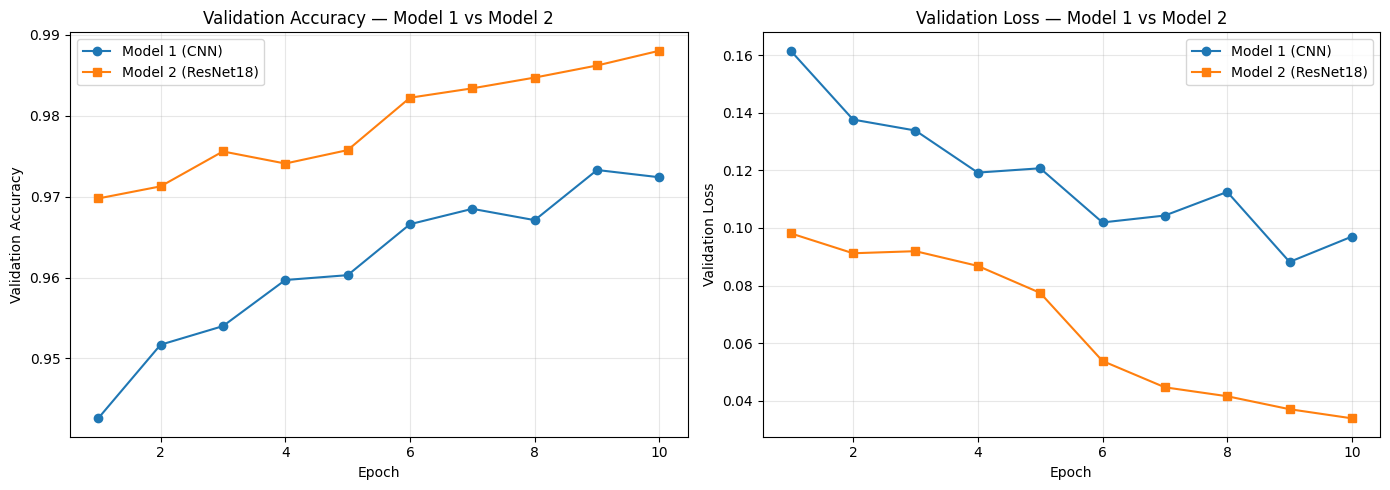

Saved model1_vs_model2_comparison.png


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(model1["epoch"], model1["val_accuracy"], "o-", label="Model 1 (CNN)")
ax1.plot(model2["epoch"], model2["val_accuracy"], "s-", label="Model 2 (ResNet18)")
ax1.set_title("Validation Accuracy — Model 1 vs Model 2")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Validation Accuracy")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(model1["epoch"], model1["val_loss"], "o-", label="Model 1 (CNN)")
ax2.plot(model2["epoch"], model2["val_loss"], "s-", label="Model 2 (ResNet18)")
ax2.set_title("Validation Loss — Model 1 vs Model 2")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Validation Loss")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("model1_vs_model2_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved model1_vs_model2_comparison.png")

## 5. Download the comparison figure

In [6]:
from google.colab import files
files.download("model1_vs_model2_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>